# Exploratory Data Analysis


In [33]:
import numpy as np
import pandas as pd
import yfinance as yf
from market_ml.data_loader import DataLoader
import matplotlib.pyplot as plt
import plotly.express as px

# Data Loading 


In [34]:
tickers = ["SPY"]
DL = DataLoader(ticker=tickers[0], period='10y', interval='1d')
spy_data = DL.load_data()
spy_df = spy_data.copy()


Data loaded for SPY


# Daily Returns

In [35]:
spy_df['Daily_Return'] = spy_df['Close'].pct_change()

spy_df[["Close", "Daily_Return"]].head()

spy_df['Daily_Return'].describe()

count    2511.000000
mean        0.000635
std         0.011312
min        -0.109424
25%        -0.003640
50%         0.000731
75%         0.005991
max         0.105019
Name: Daily_Return, dtype: float64

Text(0, 0.5, 'Frequency')

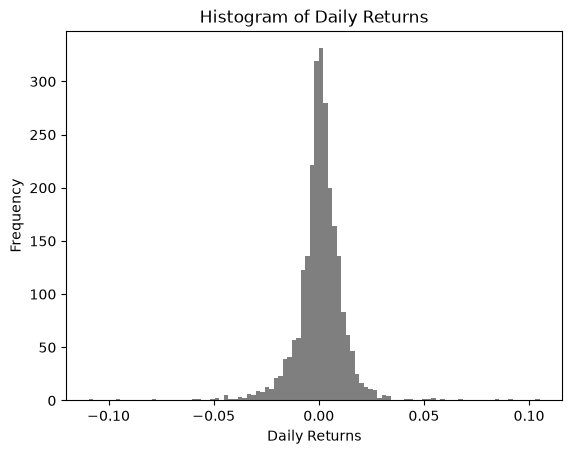

In [36]:
#looking at the distribution. 

spy_df['Daily_Return'].hist(bins=100, color='k', alpha=0.5)
plt.grid(False)
plt.title('Histogram of Daily Returns')
plt.xlabel('Daily Returns')
plt.ylabel('Frequency')

#### Daily returns mostly centered around 0.0 but some large values in the tails, showing overall the daily returns are small with some rarer big changes. 

# Volatility

In [37]:
#Volatility - 20 day rolling window
spy_df['Volatility_20D'] = spy_df['Daily_Return'].rolling(window=20).std() # 20 days is a month. 

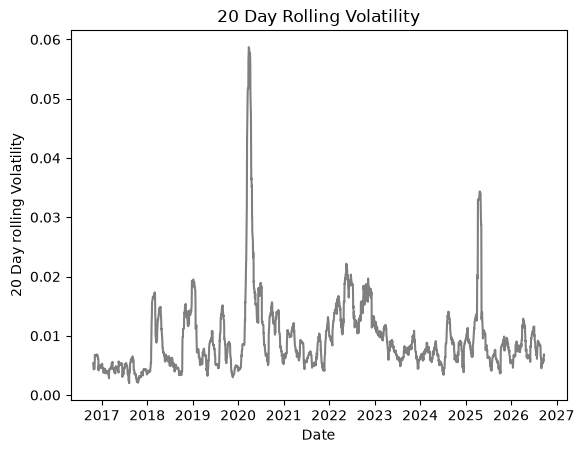

In [38]:
plt.plot(spy_df.index, spy_df['Volatility_20D'], color='k', alpha=0.5)
plt.title('20 Day Rolling Volatility')
plt.ylabel('20 Day rolling Volatility')
plt.xlabel('Date')
plt.show()

#### Rolling 20 day volatility varies with time, peaking at early 2020 (pandemic) and early 2025 (Tarrifs). Shows a need for volality to be included in the modelling. 

# Drawdown

In [39]:
#calculating the biggest drawdown

cumulative_returns = (1 + spy_df["Daily_Return"]).cumprod()

highest_peak = cumulative_returns.cummax()

spy_df['Drawdown'] = (cumulative_returns - highest_peak)/highest_peak

maximum_drawdown = spy_df['Drawdown'].min()

print(f'Maxmimum drawdown is {np.round(maximum_drawdown, 2)}')

Maxmimum drawdown is -0.34


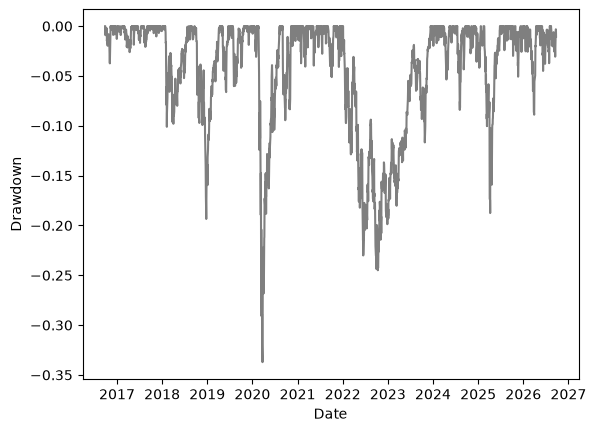

In [40]:
plt.figure(3)
plt.plot(spy_df.index, spy_df['Drawdown'], color='k', alpha=0.5)
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.show()

#### Largest drawdown occured early 2020, influenced by the pandemic but recovered by 2021. 